# Workshop on Genetics
by Kaylee Vo and Tadhg Scannell

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams["axes.linewidth"] = 1
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["mathtext.default"] = "regular"
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams["font.size"] = 12
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 14
plt.rcParams["figure.titlesize"] = 20

# Problem 1

**Define the states and construct the transition matrix of the system, in canonical form**

There are six states, based on the geneology of an individuals parents.  Those states are


*   HY: One parent is HH, the other parent is YY
*   MM: Both parents are either HY or YH
*   HM: One parent is YY and the other is either HY or YH
*   YM: One parent is YY and the other is either HY or YH
*   HH: Both parents are HH
*   YY: Both parents are YY

Given the constraint that two individuals will marry and have children only if their respective parents have the same geneotype, we can calculate the combination of outcomes for the n+1 generation couple geneotype based on the n generation couple geneotype.  

1.   For couples where their parents are HH, the only possible outcome is HH.  
The parents genes are "hh" and "hh", so all four combinations of genes results in a HH combination
2.  For couples where their parents are YY, the only possible outcome is YY.  The parents genes are "yy" and "yy", so all four combinations of genes results in a YY couple
3.   For couples where their parents are HY, the only possible outcome is MM.  The parents genes are of the combination "hh" and "yy", so the only possible outcomes are "hy" or "yh".
4.   For couples where their parents are HM, their parents are of the geneotype "hh" and either "yh" or "hy".  The possible outcomes (and associated probability) for children of this combination are "hh"(1/2), "yh"(1/4), or "hy"(1/4).  As there are two parents, we need to calculate out the matches by mulitplying the liklihood of that first parents geneotype times the liklihood that the second parent is each.  
  *    "hh" * "hh" = 0.5 * 0.5 = 1/4.  This leads to a HH generation.
  *    "hh" * "yh" = 0.5 * 0.25 = 1/8.  This leads to a HM next generation.  By symmetry, this is the same as "yh" * "hh", doubling this outcome probability to 1/4   
  *    "hh" * "hy" = 0.5 * 0.5 = 1/8.  This leads to a HM next generation. By symmetry, this is the same as "hy" * "hh", doubling this to 1/4.  
  *    "yh" * "yh" = 0.25 * 0.25 = 1/16.  This leads to a MM next generation. By symmetry, this is the same as "hy" * "yh", "yh" * "hy" and "hy" * "hy".  This leads to a total probability of 1/4.

5.   For couples where their parents are YM, their parents are of the geneotype "hh" and either "yh" or "hy".  The possible outcomes (and associated probability) for children of this combination are "yy"(1/2), "yh"(1/4), or "hy"(1/4).  As there are two parents, we need to calculate out the matches by mulitplying the liklihood of that first parents geneotype times the liklihood that the second parent is each.
  *    "yy" * "yy" = 0.5 * 0.5 = 1/4.  This leads to a YY generation.
  *    "yy" * "yh" = 0.5 * 0.25 = 1/8.  This leads to a YM next generation.  By symmetry, this is the same probability as "yh" * "yy", doubling this to 1/4.
  *    "yy" * "hy" = 0.5 * 0.5 = 1/8.  This leads to a YM next generation. By symmetry, this is the same probability as "hy" * "yy", doubling this to 1/4.  
  *    "yh" * "yh" = 0.25 * 0.25 = 1/16.  This leads to a MM next generation.  By symmetry, this is the same probability as "hy" * "yh", "yh" * "hy" and "hy" * "hy".  This leads to a total probability of 1/4.  

6. For couples where their parents are MM geneotype, their parents of the genotype combinations where both are of either are "hy" or "yh".  The possible outcomes (and associated probability) for children of this combination are "hh" (1/4), "hy" (1/4), "yh" (1/4), and "yy" (1/4). As there are two parents, we need to calculate out the matches by mulitplying the liklihood of that first parents geneotype times the liklihood that the second parent is each.
  *    "yy" * "yy" = 0.25 * 0.25 = 1/16.  This leads to a YY generation.
  *    "hh" * "hh" = 0.25 * 0.25 = 1/16.  This leads to a HH generation.
  *    "yy" * "yh" = 0.25 * 0.25 = 1/16.  This leads to a YM next generation.  By symmetry, this is the same probability as "yh" * "yy", "yy" * "hy" and "hy" * "yy" increasing this to 1/4.
  *    "hh" * "yh" = 0.25 * 0.25 = 1/16.  This leads to a HM next generation.  By symmetry, this is the same probability as "yh" * "hh", "hh" * "hy" and "hy" * "hh" increasing this to 1/4   
  *    "yh" * "yh" = 0.25 * 0.25 = 1/16.  This leads to an MM generation.  By symmetry, this is the same probability as ("hy" * "yh"), ("hy" * "hy"), ("yh" * "hy") increasing the probability to 1/4.

  *    "yy" * "hh" = .25 * .25 =1/16.  This leads to a HY next generation.  By symmetry, this is the same probability as "hh" * "yy", increasing the total probability to 1/8.



The diagram relecting this is shown below with the probabilities of each transition.

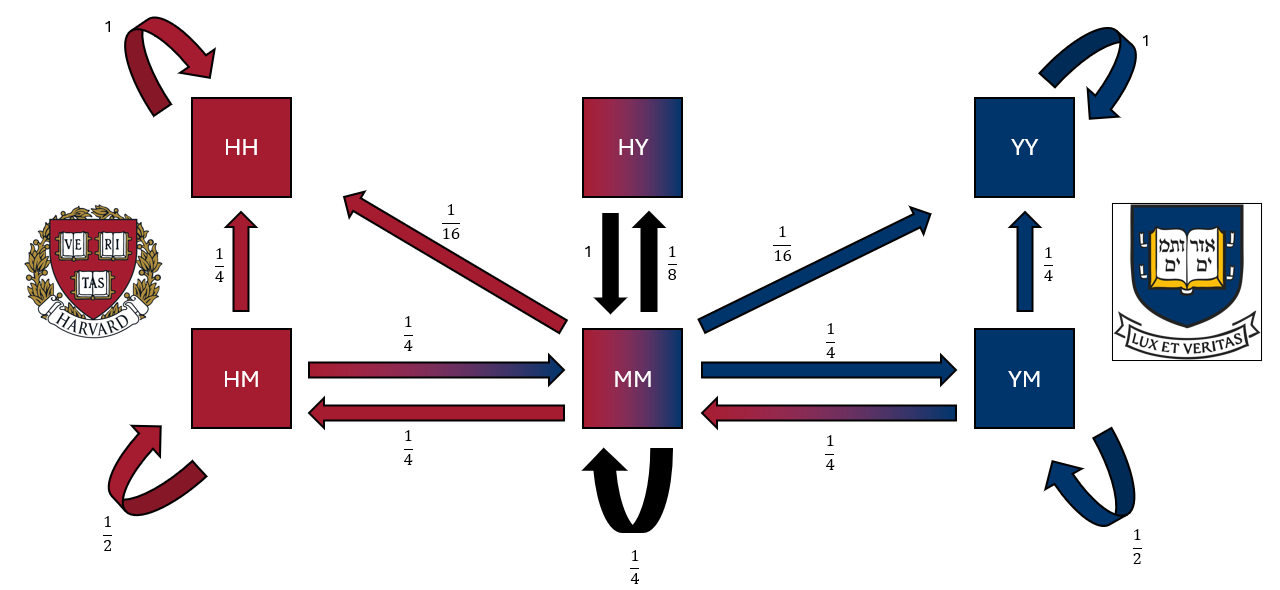

From this, it is apparent that there are two absorving states, HH and YY.  This turns into the transition matrix below, which is in the canonical form.

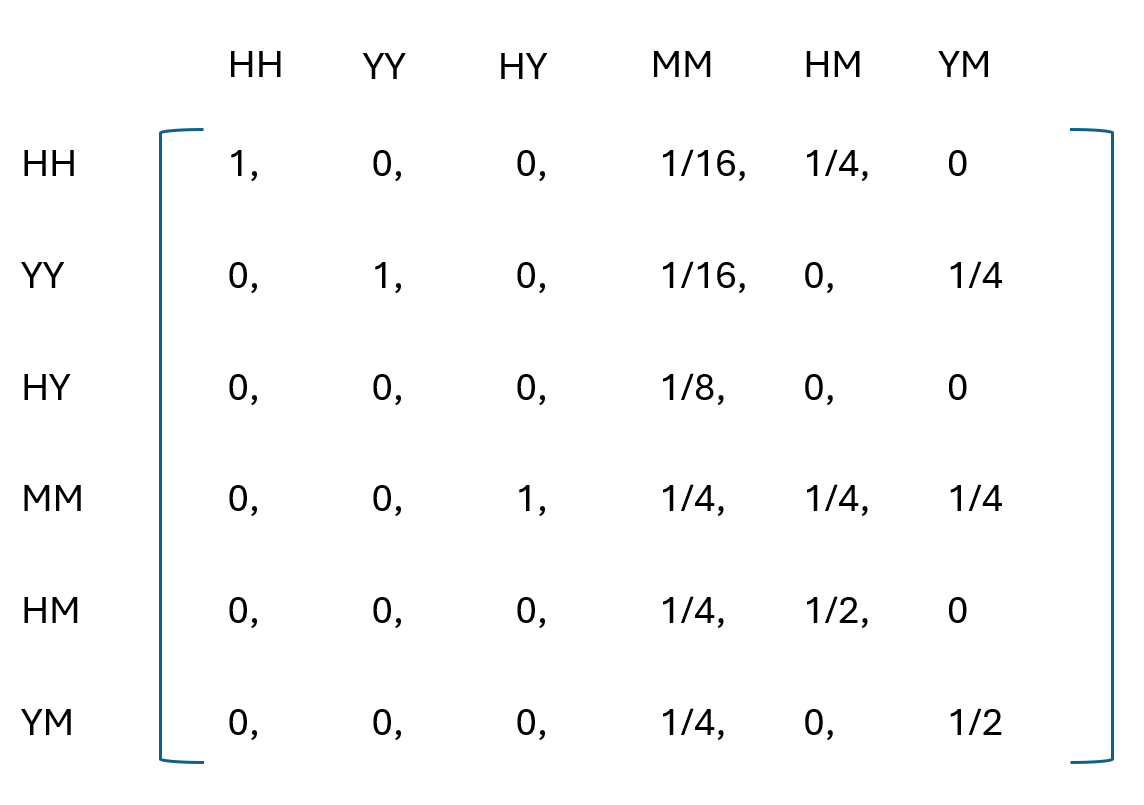

# Problem 2

Numerically evolve the probability vector (i.e. multiply the probability vector by the
transition matrix) to equilibrium for some different initial conditions as prescribed below.


How does the initial size of the student populations affect the final probabilities?

Try:
i. equal number of people of a certain phenotype:
* Y = 1/2,
* H = 1/4,
* M = 1/4

ii. equal number of people of a certain genotype:
* Y = 1/3,
* H = 1/3,
* M = 1/3

Do you agree with the MIT scientists?

The transition matrix, in python, is shown below

In [4]:
transition_matrix = [[1, 0, 0, 1/16, 1/4, 0],[0, 1, 0, 1/16, 0, 1/4],[0, 0, 0, 1/8, 0, 0],[0, 0, 1, 1/4, 1/4, 1/4],[0, 0, 0, 1/4, 1/2, 0], [0, 0, 0, 1/4, 0, 1/2]]
print(transition_matrix)

[[1, 0, 0, 0.0625, 0.25, 0], [0, 1, 0, 0.0625, 0, 0.25], [0, 0, 0, 0.125, 0, 0], [0, 0, 1, 0.25, 0.25, 0.25], [0, 0, 0, 0.25, 0.5, 0], [0, 0, 0, 0.25, 0, 0.5]]


The probability matrixes can be found by finding the combinations of each option.  

For i, the initial probabilities are
* Y * Y = 1/2 * 1/2 = 1/4
* H * H = 1/4 * 1/4 = 1/16
* H * Y = 1/4 * 1/2 = 1/8  This is the same as Y * H so the probability is increased to 1/4
* Y * M = 1/2 * 1/4 = 1/8.  This is the same as M * Y so the probability is increased to 1/4
* H * M = 1/4 * 1/4 = 1/16.  This is the same as M * Y so the probability is increased to 1/8
* M * M = 1/4 * 1/4 = 1/16

Therefore the probability matrix is:

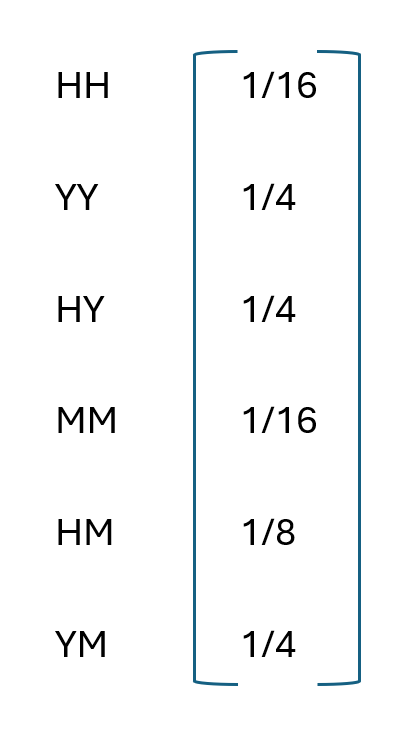

And the python variable is

In [5]:
i_probability_matrix = [[1/16],[1/4],[1/4],[1/16],[1/8], [1/4]]
print(i_probability_matrix)

[[0.0625], [0.25], [0.25], [0.0625], [0.125], [0.25]]


Now to get to the absorbing state, we multiply until only the absobing states remain

In [6]:
Number_of_Iterations = 0

matrix_to_hold=i_probability_matrix

while(round(matrix_to_hold[2][0]+matrix_to_hold[3][0]+matrix_to_hold[4][0]+matrix_to_hold[5][0], 3) != 0.0):
  matrix_to_hold = np.dot(transition_matrix, matrix_to_hold)
  Number_of_Iterations+=1

print("Number of Iterations: " + str(Number_of_Iterations))
print("Probability Matrix: ")
print(matrix_to_hold)
print("HH probability rounded two 2 decimals = " + str(round(matrix_to_hold[0][0],3)))
print("YY probability rounded two 2 decimals = " + str(round(matrix_to_hold[1][0],3)))

Number of Iterations: 35
Probability Matrix: 
[[3.74775268e-01]
 [6.24775268e-01]
 [2.50477256e-05]
 [1.62112286e-04]
 [1.31151592e-04]
 [1.31151596e-04]]
HH probability rounded two 2 decimals = 0.375
YY probability rounded two 2 decimals = 0.625


For ii, the initial probabilities are
* Y * Y = 1/3 * 1/3 = 1/9
* H * H = 1/3 * 1/3 = 1/9
* H * Y = 1/3 * 1/3 = 1/9  This is the same as Y * H so the probability is increased to 2/9
* Y * M = 1/3 * 1/3 = 1/9.  This is the same as M * Y so the probability is increased to 2/9
* H * M = 1/3 * 1/3 = 1/9.  This is the same as M * Y so the probability is increased to 2/9
* M * M = 1/3 * 1/3 = 1/9

Therefore the probability matrix is:

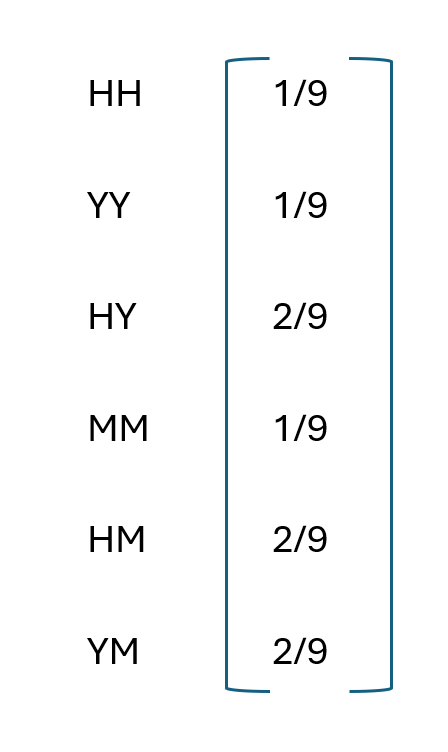

In [7]:
ii_probability_matrix = [[1/9],[1/9],[2/9],[1/9],[2/9], [2/9]]
print(ii_probability_matrix)

[[0.1111111111111111], [0.1111111111111111], [0.2222222222222222], [0.1111111111111111], [0.2222222222222222], [0.2222222222222222]]


In [8]:
Number_of_Iterations = 0

matrix_to_hold=ii_probability_matrix

while(round(matrix_to_hold[2][0]+matrix_to_hold[3][0]+matrix_to_hold[4][0]+matrix_to_hold[5][0], 3) != 0.0):
  matrix_to_hold = np.dot(transition_matrix, matrix_to_hold)
  Number_of_Iterations+=1

print("Number of Iterations: " + str(Number_of_Iterations))
print("Probability Matrix: ")
print(matrix_to_hold)
print("HH probability rounded two 2 decimals = " + str(round(matrix_to_hold[0][0],3)))
print("YY probability rounded two 2 decimals = " + str(round(matrix_to_hold[1][0],3)))

Number of Iterations: 35
Probability Matrix: 
[[4.99751807e-01]
 [4.99751807e-01]
 [2.76626427e-05]
 [1.79036385e-04]
 [1.44843478e-04]
 [1.44843478e-04]]
HH probability rounded two 2 decimals = 0.5
YY probability rounded two 2 decimals = 0.5


From this, we do not agree with the MIT scientists.  In the final states for both i and ii, where the entire population is in either abosrbing state, there are still sizeable populations of both the HH and the YY populations.

# Problem 3

Use the fundamental matrix and related analysis approach covered in class to analyze
this problem. For example, calculate the number of generations to absorption, as well as
the probability of each outcome as function of the initial state.

To calculate the fundamental matrix, we start by getting the Q matrix from the transition matrix. There are two absorbing states, at HH and YY.  Therefore, the Q matrix is of the values below:

In [9]:
transition_matrix

hold=np.array(transition_matrix)

Q_matrix = hold[2:,2:]
print(Q_matrix)

[[0.    0.125 0.    0.   ]
 [1.    0.25  0.25  0.25 ]
 [0.    0.25  0.5   0.   ]
 [0.    0.25  0.    0.5  ]]


Next, we need the identity matrix to match, shown below.

In [10]:
identity_matrix = np.identity(4)
print(identity_matrix)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


We then find I-Q to get the below:

In [11]:
I_minus_Q_matrix = identity_matrix - Q_matrix
print(I_minus_Q_matrix)

[[ 1.    -0.125  0.     0.   ]
 [-1.     0.75  -0.25  -0.25 ]
 [ 0.    -0.25   0.5    0.   ]
 [ 0.    -0.25   0.     0.5  ]]


And take the inverse to find the fundamental matrix:

In [12]:
Fundamental_Matrix = np.linalg.inv(I_minus_Q_matrix)
print(Fundamental_Matrix)

[[1.33333333 0.33333333 0.16666667 0.16666667]
 [2.66666667 2.66666667 1.33333333 1.33333333]
 [1.33333333 1.33333333 2.66666667 0.66666667]
 [1.33333333 1.33333333 0.66666667 2.66666667]]


The number of steps before absorption for each state is then given by the sum of values in the associated column.  From the Fundamental Matrix, the values ( rounded to two decimals) are as follows

* HY : 6.66 steps
* MM : 5.66 steps
* HM : 4.83 steps
* YM : 4.83 steps

To calculate the probabilities, we need to take the fundamental matrix and multiply it by the R matrix of the transition matrix, shown below.

In [13]:
R_Matrix = hold[0:2,2:]
print(R_Matrix)

[[0.     0.0625 0.25   0.    ]
 [0.     0.0625 0.     0.25  ]]


In [14]:
B_Matrix = np.dot(R_Matrix, Fundamental_Matrix)
print(B_Matrix)

[[0.5  0.5  0.75 0.25]
 [0.5  0.5  0.25 0.75]]


And the probabilities of ending up in each absorbing state for each non-absorbing starting point are as follows:

* Non Absorbing State HY.  HH: 50%, YY: 50%
* Non Absorbing State MM.  HH: 50%, YY: 50%
* Non Absorbing State HY.  HM: 75%, YY: 25%
* Non Absorbing State HY.  HH: 25%, YY: 75%

# Problem 4

Compare your results from 2i and 2ii to a stochastic individual agent simulation: begin with initial set of agents with phenotype or genotype distributions as in 2i and 2ii and keep track of the evolving populations based on the imposed rules. Use a random number generator to decide on probabilistic outcome when needed. Perform many simulations and compare some key statistics to those found from the fundamental matrix.

We start by building a class to represent a single agent, with an id, a set of genes, a parents genotype and a married value used to check if an individual is matched.  We also include a spouse id just for tracking purposes.

In [15]:
class IvyLeaguer:
    def __init__(self, id, genes, parents_geneotype):
        self.id = id
        self.genes = genes
        self.parents_geneotype = parents_geneotype
        self.married = False
        self.spouse_id = None

We then built a function that takes in a population size, and percentages for each of the different populations to build our initial population.

In [16]:
def initialize_population(populationSize, harvardPercentage, yalePercentage, mixedPercentage):
  # Initialize
  population = []

  for i in range(populationSize):
    print
    determination_variable = np.random.random()

    if determination_variable < HARVARD_PERCENTAGE:
      genes = "HH"
      population.append(IvyLeaguer(i, genes, None))
    elif determination_variable < YALE_PERCENTAGE+HARVARD_PERCENTAGE:
      genes = "YY"
      population.append(IvyLeaguer(i, genes, None))
    else:
      new_determination_variable = np.random.random()
      if new_determination_variable < .5:
        genes = "HY"
        population.append(IvyLeaguer(i, genes, None))
      else:
        genes = "YH"
        population.append(IvyLeaguer(i, genes, None))

  return population

This function checks compaitbility of two members in the population.  This is mainly to clean up the execution code.

In [17]:
def check_compatibility(romeo, juliet):
  if (romeo.id != juliet.id) and (romeo.married==False and juliet.married == False) and (romeo.parents_geneotype == romeo.parents_geneotype):
        return True
  return False

This function matches two members in the population.  This is mainly to clean up the execution code.

In [18]:
def marriage(romeo, juliet):
  romeo.spouse_id = juliet.id
  juliet.spouse_id = romeo.id
  romeo.married = True
  juliet.married = True

This function creates a new member of the population.  This is mainly to clean up the execution code.

In [19]:
def create_child(child_id, romeo, juliet):
    determination_variable = np.random.random()

    # Determine Child Genes
    if determination_variable < 0.25:
        child_genes = romeo.genes[0] + juliet.genes[0]
    elif determination_variable < 0.5:
        child_genes = juliet.genes[0] + romeo.genes[1]
    elif determination_variable < 0.75:
        child_genes = juliet.genes[1] + romeo.genes[0]
    else:
        child_genes = romeo.genes[1] + juliet.genes[1]


    parent_genes=[]
    # Get Parent Geneotype
    match romeo.genes:
      case "HH":
        parent_genes.append("H")
      case "YY":
        parent_genes.append("Y")
      case "HY":
        parent_genes.append("M")
      case "YH":
        parent_genes.append("M")

    # Get Parent Geneotype
    match juliet.genes:
      case "HH":
        parent_genes.append("H")
      case "YY":
        parent_genes.append("Y")
      case "HY":
        parent_genes.append("M")
      case "YH":
        parent_genes.append("M")

    return IvyLeaguer(child_id, child_genes, parent_genes)

This function takes in the current generation, the number of children and the id start point for the next generation and returns the next generation.

In [20]:
# Population Finds Spouses

def iterate_generation(population, number_of_children, id_start):
  next_generation = []

  next_id=id_start

  for member in population:
    if member.married == False:

      for other_member in population:

        if check_compatibility(member, other_member):
          marriage(member, other_member)

          for i in range(number_of_children):
            next_generation.append(create_child(next_id, member, other_member))
            next_id+=1

          break


  return next_generation



This is a single iteration of running the simulation with 1/3, 1/3, 1/3 splits.  The outputs can be seen from the print values.

In [21]:
Number_of_Generations = 0
harvard_count=0
yale_count=0
mixed_count=1

#Set Population Variables
HARVARD_PERCENTAGE = 1/3
YALE_PERCENTAGE = 1/3
MIXED_PERCENTAGE = 1/3
populationSize = 1000

#Population Array
population = initialize_population(populationSize, HARVARD_PERCENTAGE, YALE_PERCENTAGE, MIXED_PERCENTAGE)

while not (mixed_count == 0)  :
  Number_of_Generations+=1
  population = iterate_generation(population, 2, 101)
  harvard_count=0
  yale_count=0
  mixed_count=0
  for x in population:
    if x.genes == "HH":
      harvard_count+=1
    elif x.genes == "YY":
      yale_count+=1
    elif x.genes == "HY" or "YH":
      mixed_count+=1
    else:
      print("Weird Genes: " + i.genes)
  Number_of_Generations += 1

print("Generation: " + str(Number_of_Generations))
print("Harvard Count: " + str(harvard_count))
print("Yale Count: " + str(yale_count))
print("Mixed Count: " + str(mixed_count))

Generation: 58
Harvard Count: 456
Yale Count: 544
Mixed Count: 0


This is a single iteration of the yale = 1/2, harvard = 1/4 and mixed = 1/4 populations.  The output can be seen below.

In [22]:
Number_of_Generations = 0
harvard_count=0
yale_count=0
mixed_count=1

#Set Population Variables
HARVARD_PERCENTAGE = 1/4
YALE_PERCENTAGE = 1/2
MIXED_PERCENTAGE = 1/4
populationSize = 1000

#Population Array
population = initialize_population(populationSize, HARVARD_PERCENTAGE, YALE_PERCENTAGE, MIXED_PERCENTAGE)

while not (mixed_count == 0)  :
  Number_of_Generations+=1
  population = iterate_generation(population, 2, 101)
  harvard_count=0
  yale_count=0
  mixed_count=0
  for x in population:
    if x.genes == "HH":
      harvard_count+=1
    elif x.genes == "YY":
      yale_count+=1
    elif x.genes == "HY" or "YH":
      mixed_count+=1
    else:
      print("Weird Genes: " + i.genes)
  Number_of_Generations += 1

print("Generation: " + str(Number_of_Generations))
print("Harvard Count: " + str(harvard_count))
print("Yale Count: " + str(yale_count))
print("Mixed Count: " + str(mixed_count))

Generation: 68
Harvard Count: 370
Yale Count: 630
Mixed Count: 0


Now we do multiple simulations.  For this exercise, we have done six and plotted the population over a known number of simulations and generation counts.  The output can be seen in the charts resulting beneath.  This is for hte yale = 1/2, harvard = 1/4, and mixed = 1/4 initial population distributions.

Generation: 100
Harvard Count: 348
Yale Count: 652
Mixed Count: 0


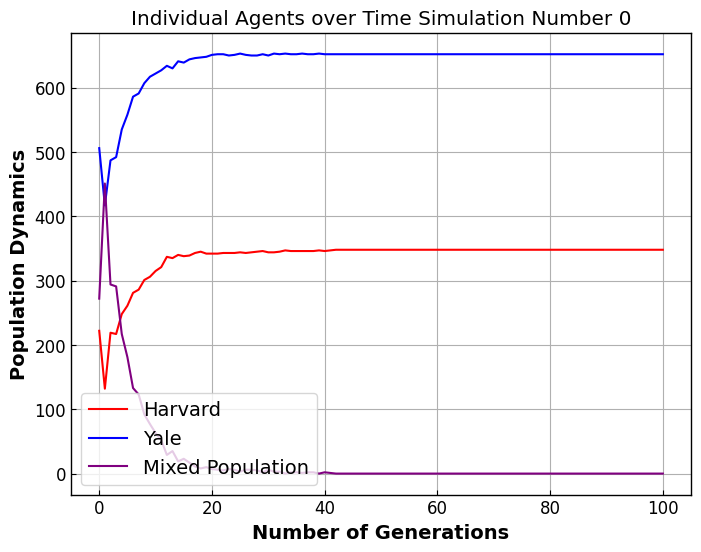

Generation: 100
Harvard Count: 406
Yale Count: 594
Mixed Count: 0


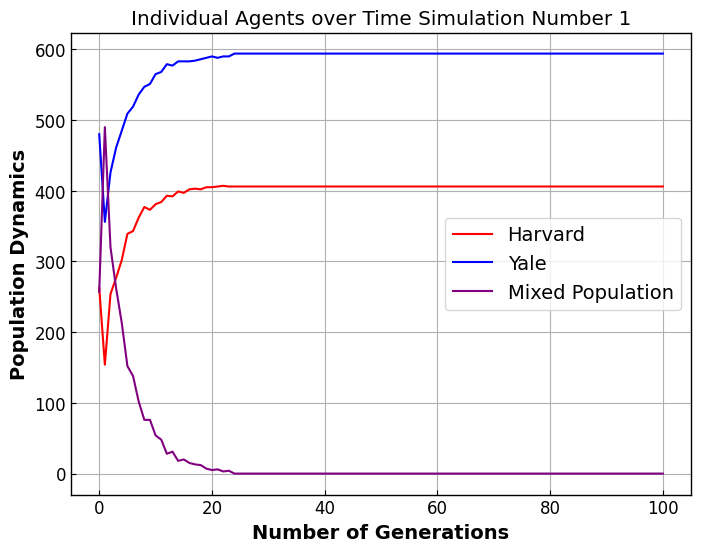

Generation: 100
Harvard Count: 386
Yale Count: 614
Mixed Count: 0


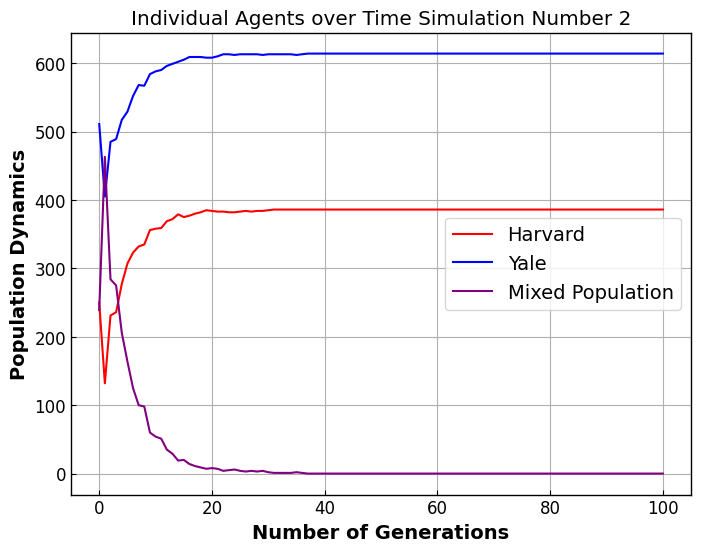

Generation: 100
Harvard Count: 364
Yale Count: 636
Mixed Count: 0


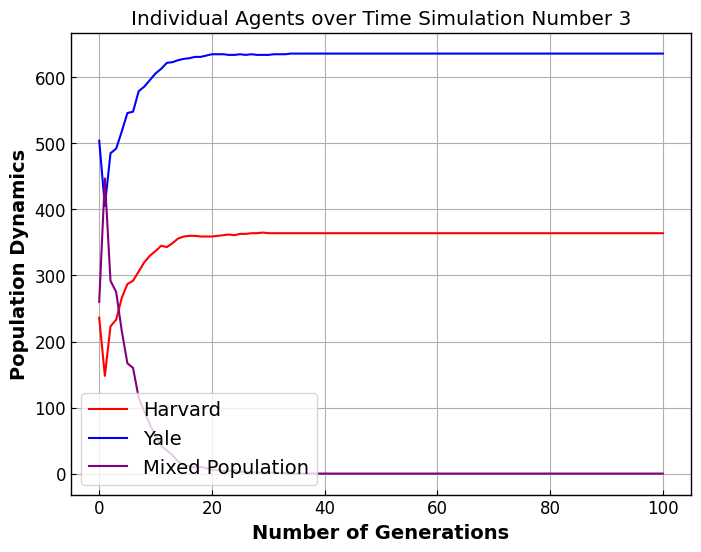

Generation: 100
Harvard Count: 390
Yale Count: 610
Mixed Count: 0


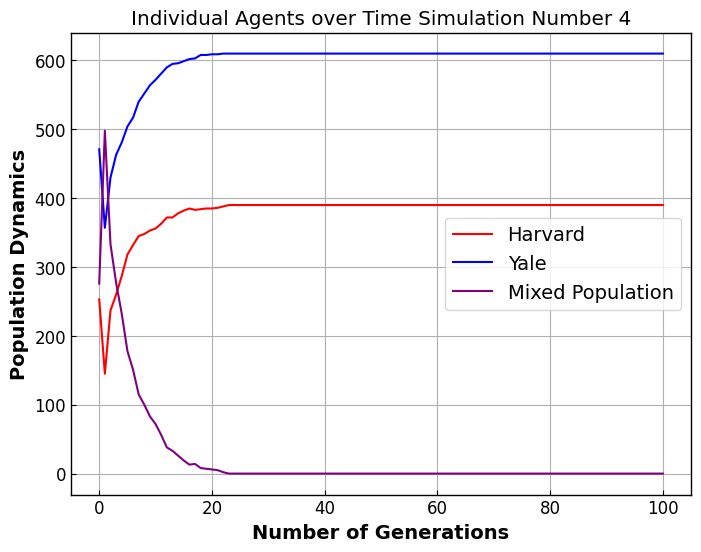

Generation: 100
Harvard Count: 354
Yale Count: 646
Mixed Count: 0


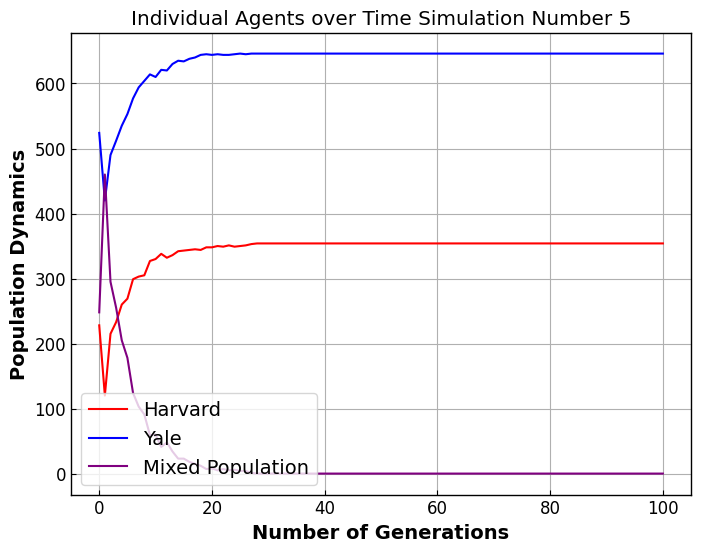

In [23]:
#Set Population Variables
HARVARD_PERCENTAGE = 1/4
YALE_PERCENTAGE = 1/2
MIXED_PERCENTAGE = 1/4
populationSize = 1000
simulation_count = 6
NUMBER_OF_CHILDREN = 2
GENERATIONS = 100

for y in range(simulation_count):

    Number_of_Generations = 0
    harvard_count=0
    yale_count=0
    mixed_count=0
    x_plot = []
    harvard_pop = []
    yale_pop =  []
    mixed_pop =  []
    population = []
    #Population Array
    population = initialize_population(populationSize, HARVARD_PERCENTAGE, YALE_PERCENTAGE, MIXED_PERCENTAGE)
    for x in population:
      if x.genes == "HH":
        harvard_count+=1
      elif x.genes == "YY":
        yale_count+=1
      elif x.genes == "HY" or "YH":
        mixed_count+=1
    x_plot.append(Number_of_Generations)
    harvard_pop.append(harvard_count)
    yale_pop.append(yale_count)
    mixed_pop.append(mixed_count)



    for i in range(GENERATIONS):

      Number_of_Generations+=1
      population = iterate_generation(population, NUMBER_OF_CHILDREN, 0)
      harvard_count=0
      yale_count=0
      mixed_count=0
      for x in population:
        if x.genes == "HH":
          harvard_count+=1
        elif x.genes == "YY":
          yale_count+=1
        elif x.genes == "HY" or "YH":
          mixed_count+=1
        else:
          print("Weird Genes: " + i.genes)
      x_plot.append(Number_of_Generations)
      harvard_pop.append(harvard_count)
      yale_pop.append(yale_count)
      mixed_pop.append(mixed_count)

    print("Generation: " + str(Number_of_Generations))
    print("Harvard Count: " + str(harvard_count))
    print("Yale Count: " + str(yale_count))
    print("Mixed Count: " + str(mixed_count))

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(x_plot, harvard_pop, label="Harvard", color="red")
    ax.plot(x_plot, yale_pop, label="Yale", color="blue")
    ax.plot(x_plot, mixed_pop, label="Mixed Population", color="purple")
    ax.set_xlabel("Number of Generations")
    ax.set_ylabel("Population Dynamics")
    ax.set_title("Individual Agents over Time Simulation Number " + str(y))

    ax.legend()
    ax.grid()
    plt.show()

Next, we run the same code for the equal distributions of the initial populations.

Generation: 100
Harvard Count: 468
Yale Count: 532
Mixed Count: 0


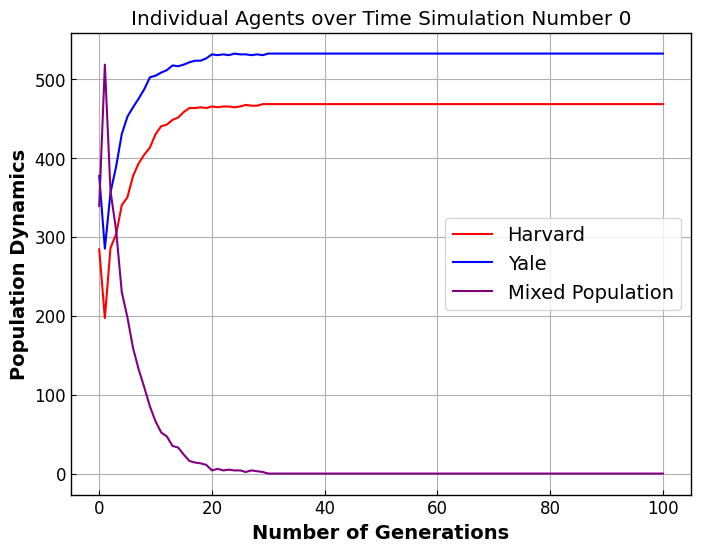

Generation: 100
Harvard Count: 504
Yale Count: 496
Mixed Count: 0


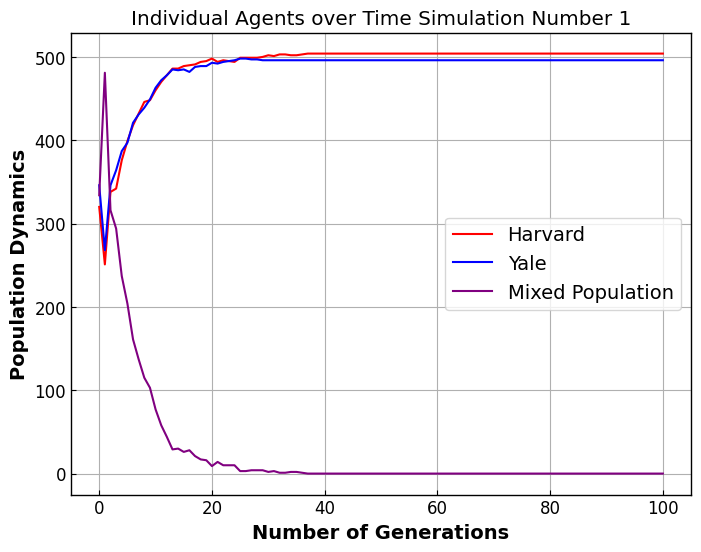

Generation: 100
Harvard Count: 458
Yale Count: 542
Mixed Count: 0


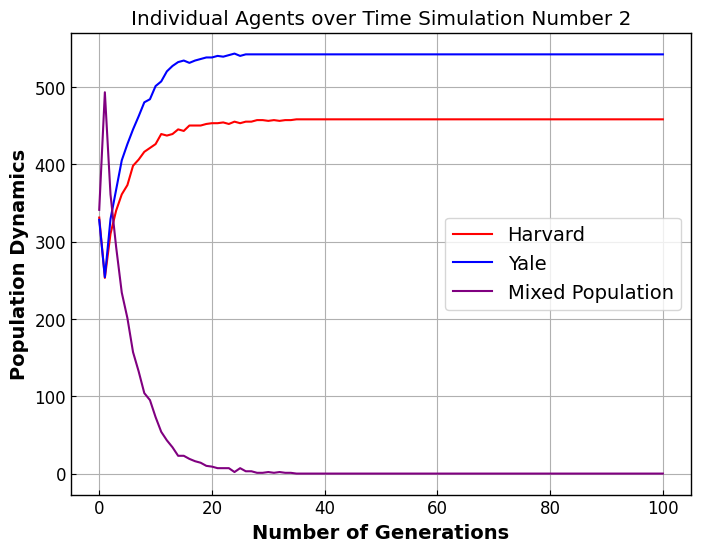

Generation: 100
Harvard Count: 500
Yale Count: 500
Mixed Count: 0


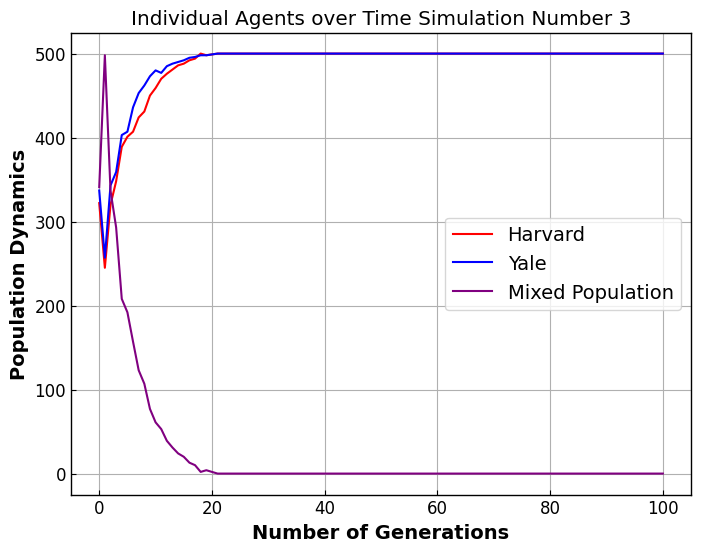

Generation: 100
Harvard Count: 504
Yale Count: 496
Mixed Count: 0


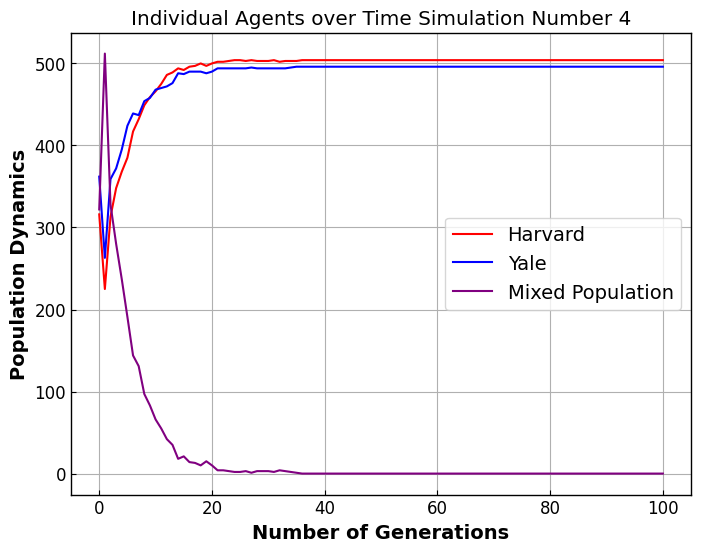

Generation: 100
Harvard Count: 472
Yale Count: 528
Mixed Count: 0


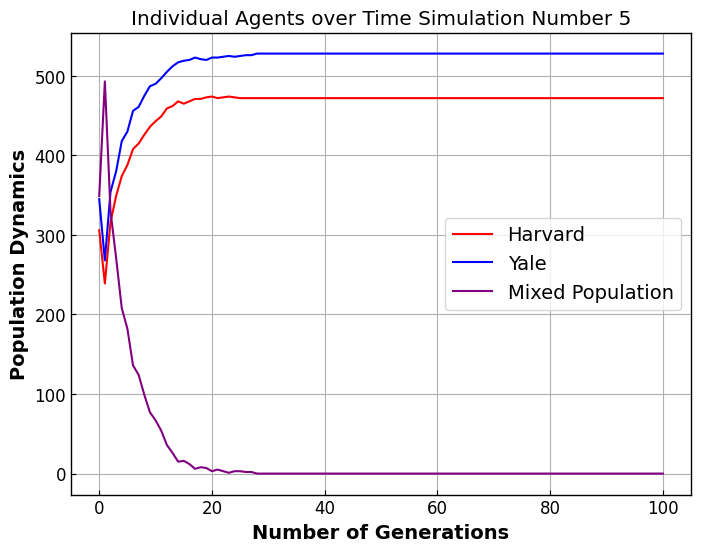

In [25]:
#Set Population Variables
HARVARD_PERCENTAGE = 1/3
YALE_PERCENTAGE = 1/3
MIXED_PERCENTAGE = 1/3
populationSize = 1000
simulation_count = 6
NUMBER_OF_CHILDREN = 2
GENERATIONS = 100

for y in range(simulation_count):

    Number_of_Generations = 0
    harvard_count=0
    yale_count=0
    mixed_count=0
    x_plot = []
    harvard_pop = []
    yale_pop =  []
    mixed_pop =  []
    population = []
    #Population Array
    population = initialize_population(populationSize, HARVARD_PERCENTAGE, YALE_PERCENTAGE, MIXED_PERCENTAGE)
    for x in population:
      if x.genes == "HH":
        harvard_count+=1
      elif x.genes == "YY":
        yale_count+=1
      elif x.genes == "HY" or "YH":
        mixed_count+=1
    x_plot.append(Number_of_Generations)
    harvard_pop.append(harvard_count)
    yale_pop.append(yale_count)
    mixed_pop.append(mixed_count)



    for i in range(GENERATIONS):

      Number_of_Generations+=1
      population = iterate_generation(population, NUMBER_OF_CHILDREN, 0)
      harvard_count=0
      yale_count=0
      mixed_count=0
      for x in population:
        if x.genes == "HH":
          harvard_count+=1
        elif x.genes == "YY":
          yale_count+=1
        elif x.genes == "HY" or "YH":
          mixed_count+=1
        else:
          print("Weird Genes: " + i.genes)
      x_plot.append(Number_of_Generations)
      harvard_pop.append(harvard_count)
      yale_pop.append(yale_count)
      mixed_pop.append(mixed_count)

    print("Generation: " + str(Number_of_Generations))
    print("Harvard Count: " + str(harvard_count))
    print("Yale Count: " + str(yale_count))
    print("Mixed Count: " + str(mixed_count))

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(x_plot, harvard_pop, label="Harvard", color="red")
    ax.plot(x_plot, yale_pop, label="Yale", color="blue")
    ax.plot(x_plot, mixed_pop, label="Mixed Population", color="purple")
    ax.set_xlabel("Number of Generations")
    ax.set_ylabel("Population Dynamics")
    ax.set_title("Individual Agents over Time Simulation Number " + str(y))

    ax.legend()
    ax.grid()
    plt.show()

Looking at these charts, we see that they take longer than the analytic solutions to acheive absorbing states.  The models take between 20 and 40 generations to acheive the absorbing states.